# Intrinsic Dimensionality of S&P 500 Returns

Proof-of-concept notebook applying three intrinsic-dimension estimators to CRSP daily returns:

1. **Random Matrix Theory (RMT)** — Marchenko-Pastur upper edge as a noise threshold
2. **Participation Ratio** — continuous spectral concentration measure
3. **Levina-Bickel** — nearest-neighbor MLE estimator

Data sources (all in `data_raw/`):
- `sp500_returns_matrix.parquet` — daily returns, trading-days × PERMNO-labeled tickers
- `sp500_constituent_history.parquet` — S&P 500 membership snapshots
- `permno_ticker_map.parquet` — PERMNO ↔ ticker ↔ company-name mapping from CRSP `msenames`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from sklearn.neighbors import NearestNeighbors
from collections import Counter

%matplotlib inline
np.set_printoptions(precision=4, suppress=True)
SEED = 6740

## 1. Data Loading & Cleaning

Load all three CRSP-derived parquet files. The cleaning recipe:

1. Pick an `as-of` date and an analysis window
2. Restrict the asset universe to **actual S&P 500 members** at the as-of date (uses `constituent_history`, not just "stocks with data" — addresses survivorship bias)
3. Within the window, drop assets missing any return — guarantees no implicit imputation
4. Cast to `float` (the parquet uses pandas nullable `Float64`, which must be coerced before NumPy math)

In [2]:
returns_full = pd.read_parquet("data_raw/sp500_returns_matrix.parquet")
returns_full.index = pd.to_datetime(returns_full.index)
returns_full = returns_full.sort_index()

constituent_history = pd.read_parquet("data_raw/sp500_constituent_history.parquet")
constituent_history["date"] = pd.to_datetime(constituent_history["date"])
constituent_history = constituent_history.sort_values("date").reset_index(drop=True)

permno_ticker_map = pd.read_parquet("data_raw/permno_ticker_map.parquet")

print(f"returns_full:        {returns_full.shape}, {returns_full.index.min().date()} \u2192 {returns_full.index.max().date()}")
print(f"constituent_history: {constituent_history.shape}, {len(constituent_history)} membership snapshots")
print(f"permno_ticker_map:   {permno_ticker_map.shape}")

returns_full:        (6226, 1305), 2000-04-03 → 2024-12-31
constituent_history: (2187, 2), 2187 membership snapshots
permno_ticker_map:   (5420, 5)


In [3]:
# Helper 1: S&P members as of any date (binary search on snapshot dates)
def members_as_of(date, history=constituent_history):
    target = pd.to_datetime(date)
    idx = history["date"].searchsorted(target, side="right") - 1
    if idx < 0:
        raise ValueError(f"No constituent record on or before {date}")
    return set(history.iloc[idx]["tickers"].split(","))


# Helper 2: returns_full column \u2192 base ticker (strip the _PERMNO suffix used
# only when CRSP reused a ticker across companies). Cached as a Series.
_base_ticker = pd.Series(
    [c.split("_")[0] for c in returns_full.columns],
    index=returns_full.columns,
)


def members_to_columns(member_tickers):
    """Vectorized: returns_full columns whose base ticker is in the membership set."""
    return returns_full.columns[_base_ticker.isin(member_tickers)]


# Helper 3: column label \u2192 (ticker, company name) using permno_ticker_map
_pt_latest = permno_ticker_map.sort_values("namedt").groupby("permno", as_index=False).last()[["permno", "ticker", "comnam"]]
_ticker_freq = Counter(_pt_latest["ticker"])
_pt_latest["col_label"] = _pt_latest.apply(
    lambda r: f"{r['ticker']}_{r['permno']}" if _ticker_freq[r["ticker"]] > 1 else r["ticker"],
    axis=1,
)
col_to_company = dict(zip(_pt_latest["col_label"], _pt_latest["comnam"]))

print("Helpers ready.")
print(f"  Example \u2014 members_as_of('2019-12-31'):  {len(members_as_of('2019-12-31'))} tickers")
print(f"  Example \u2014 col_to_company['ORCL']:       {col_to_company.get('ORCL')}")
print(f"  Example \u2014 col_to_company['JAVA_10078']: {col_to_company.get('JAVA_10078')}")

Helpers ready.
  Example — members_as_of('2019-12-31'):  505 tickers
  Example — col_to_company['ORCL']:       ORACLE CORP
  Example — col_to_company['JAVA_10078']: SUN MICROSYSTEMS INC


In [4]:
# Single-window analysis. 2-year pre-COVID baseline keeps q = p/n < 1
# and avoids the 2020 vol spike contaminating the noise-bulk estimate.
AS_OF_DATE = "2019-12-31"
WINDOW_START = "2018-01-01"
WINDOW_END = "2019-12-31"

# Step 1: real S&P 500 membership at the as-of date
members = members_as_of(AS_OF_DATE)
member_cols = members_to_columns(members)

# Step 2: slice to window and member columns
returns_win = returns_full.loc[WINDOW_START:WINDOW_END, member_cols]

# Step 3: drop assets with any missing return in the window (no imputation)
returns_win = returns_win.dropna(axis=1, how="any")

# Step 4: cast pandas nullable Float64 \u2192 NumPy float64 for downstream math
X_raw = returns_win.to_numpy(dtype=float)
n, p = X_raw.shape
q = p / n

print(f"As-of date:                {AS_OF_DATE}")
print(f"S&P members at as-of:      {len(members)}")
print(f"Members with any data:     {len(member_cols)}")
print(f"Members with full window:  {p}")
print(f"Window:                    {WINDOW_START} \u2192 {WINDOW_END}")
print(f"  n (days):                {n}")
print(f"  p (assets):              {p}")
print(f"  q = p/n:                 {q:.3f}")

As-of date:                2019-12-31
S&P members at as-of:      505
Members with any data:     588
Members with full window:  489
Window:                    2018-01-01 → 2019-12-31
  n (days):                503
  p (assets):              489
  q = p/n:                 0.972


In [5]:
# Demean (column-wise) and build covariance via X.T @ X (faster than .cov())
X = X_raw - X_raw.mean(axis=0, keepdims=True)
cov = (X.T @ X) / (n - 1)

# Symmetric eigendecomposition. eigh returns ascending; flip to descending.
evals, evecs = eigh(cov)
evals = evals[::-1]
evecs = evecs[:, ::-1]

print(f"Covariance shape:     {cov.shape}")
print(f"Top 5 eigenvalues:    {evals[:5]}")
print(f"Total variance (\u03a3\u03bb): {evals.sum():.6e}")
print(f"Top eig share:        {evals[0] / evals.sum():.1%}")

Covariance shape:     (489, 489)
Top 5 eigenvalues:    [0.0461 0.0068 0.0046 0.0039 0.0035]
Total variance (Σλ): 1.529194e-01
Top eig share:        30.1%


## 2. Method 1 — Random Matrix Theory (Marchenko-Pastur)

Under the null that returns are i.i.d. noise, eigenvalues of the sample covariance follow the Marchenko-Pastur distribution with continuous support on $[\lambda_-, \lambda_+]$ where

$$\lambda_\pm = \sigma^2 (1 \pm \sqrt{q})^2, \qquad q = p/n.$$

Eigenvalues above $\lambda_+$ are statistically distinguishable from noise — these are the **signal** modes.

**Estimating σ² is the hard part, and the naive median-of-bottom-half estimator is biased.** When $q \approx 1$ the MP bulk extends down toward zero, so the lower half of the empirical spectrum is dominated by the small-eigenvalue tail of the bulk, not by an unbiased noise sample. We compare three estimators and use the iterative one as canonical:

1. **Bottom-half median** — naive baseline.
2. **Iterative trimming** (Laloux et al. 2000): start with σ² = mean of all eigenvalues, compute the implied λ₊, drop eigenvalues above it, recompute σ² from the remainder, iterate to a fixed point.
3. **MP density fit**: choose σ² that minimizes the L² distance between the empirical bulk histogram and the theoretical MP density.

In [6]:
from scipy.optimize import minimize_scalar


def mp_density(lam, sigma2_, q_):
    """Marchenko-Pastur continuous density at points `lam`."""
    lam_p = sigma2_ * (1 + np.sqrt(q_)) ** 2
    lam_m = sigma2_ * (1 - np.sqrt(q_)) ** 2
    out = np.zeros_like(lam, dtype=float)
    inside = (lam > lam_m) & (lam < lam_p)
    out[inside] = np.sqrt((lam_p - lam[inside]) * (lam[inside] - lam_m)) / (2 * np.pi * sigma2_ * q_ * lam[inside])
    return out


def iter_sigma2(evals_, q_, max_iter=100, tol=1e-12):
    """Iteratively trim eigenvalues above the implied MP edge; σ² is the mean of what remains."""
    sigma2_ = evals_.mean()
    for _ in range(max_iter):
        edge = sigma2_ * (1 + np.sqrt(q_)) ** 2
        keep = evals_ <= edge
        if keep.sum() == 0:
            break
        new_sigma2 = evals_[keep].mean()
        if abs(new_sigma2 - sigma2_) < tol * sigma2_:
            sigma2_ = new_sigma2
            break
        sigma2_ = new_sigma2
    return sigma2_


def fit_sigma2(evals_, q_, bulk_quantile=0.9, n_bins=50):
    """Choose σ² to minimize L² distance between empirical bulk histogram and MP density."""
    cutoff = np.quantile(evals_, bulk_quantile)
    bulk = evals_[evals_ <= cutoff]
    hist, edges = np.histogram(bulk, bins=n_bins, density=True)
    centers = 0.5 * (edges[1:] + edges[:-1])
    s0 = evals_.mean()
    res = minimize_scalar(
        lambda s2: np.sum((hist - mp_density(centers, s2, q_)) ** 2),
        bounds=(s0 * 0.05, s0 * 5),
        method="bounded",
    )
    return res.x


def rmt_count(s2, evs, q_):
    return int((evs > s2 * (1 + np.sqrt(q_)) ** 2).sum())


# Compare the three σ² estimators on the single-window spectrum
sigma2_median = np.median(evals[p // 2 :])
sigma2_iter = iter_sigma2(evals, q)
sigma2_fit = fit_sigma2(evals, q)

print(f"{'method':<22}  {'σ²':>14}  {'λ+':>14}  {'#signal':>8}")
for name, s2 in [
    ("bottom-half median", sigma2_median),
    ("iterative trim", sigma2_iter),
    ("MP density fit", sigma2_fit),
]:
    edge = s2 * (1 + np.sqrt(q)) ** 2
    print(f"{name:<22}  {s2:>14.4e}  {edge:>14.4e}  {rmt_count(s2, evals, q):>8d}")

# Canonical: iterative trim
sigma2 = sigma2_iter
mp_upper = sigma2 * (1 + np.sqrt(q)) ** 2
mp_lower = sigma2 * (1 - np.sqrt(q)) ** 2 if q < 1 else 0.0
rmt_dim = rmt_count(sigma2, evals, q)
print(f"\nCanonical RMT dimension (iterative): {rmt_dim}")
print(f"Top {min(rmt_dim, 10)} signal eigenvalues: {evals[:min(rmt_dim, 10)]}")

method                              σ²              λ+   #signal
bottom-half median          1.1042e-05      4.3553e-05       270
iterative trim              4.1321e-05      1.6298e-04       149
MP density fit              4.0122e-05      1.5825e-04       152

Canonical RMT dimension (iterative): 149
Top 10 signal eigenvalues: [0.0461 0.0068 0.0046 0.0039 0.0035 0.0027 0.0024 0.0019 0.0017 0.0016]


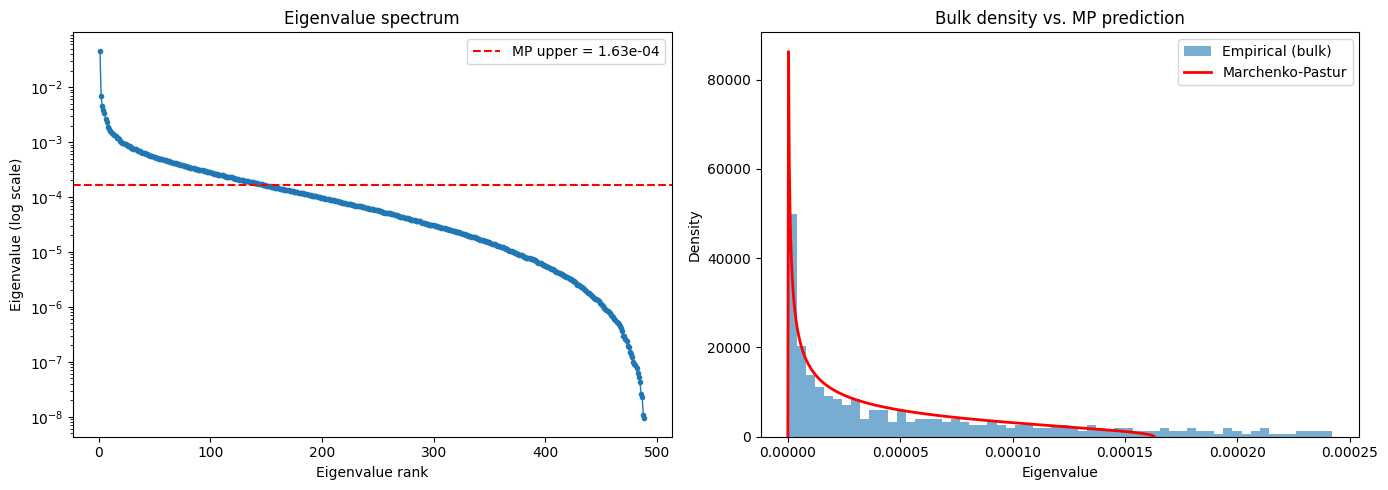

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full spectrum (log scale) with MP threshold
axes[0].plot(np.arange(1, len(evals) + 1), evals, marker=".", linestyle="-", linewidth=1)
axes[0].axhline(mp_upper, color="red", linestyle="--", label=f"MP upper = {mp_upper:.2e}")
axes[0].set_xlabel("Eigenvalue rank")
axes[0].set_ylabel("Eigenvalue (log scale)")
axes[0].set_yscale("log")
axes[0].set_title("Eigenvalue spectrum")
axes[0].legend()

# Right: empirical density of the bulk vs. theoretical MP density
bulk = evals[evals < mp_upper * 1.5]
axes[1].hist(bulk, bins=60, density=True, alpha=0.6, label="Empirical (bulk)")

lam = np.linspace(max(mp_lower, 1e-12), mp_upper, 500)
mp_density = np.sqrt(np.maximum((mp_upper - lam) * (lam - mp_lower), 0)) / (2 * np.pi * sigma2 * q * lam)
axes[1].plot(lam, mp_density, color="red", linewidth=2, label="Marchenko-Pastur")
axes[1].set_xlabel("Eigenvalue")
axes[1].set_ylabel("Density")
axes[1].set_title("Bulk density vs. MP prediction")
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Method 2 — Participation Ratio

$$D_{PR} = \frac{(\sum_i \lambda_i)^2}{\sum_i \lambda_i^2}$$

If one eigenvalue dominates the spectrum, $D_{PR} \to 1$. If all eigenvalues are equal, $D_{PR} = p$. It's a continuous, soft measure of how spread-out variance is across the spectrum — sensitive to the tail shape rather than a hard threshold.

In [8]:
pr_dim = (evals.sum() ** 2) / (evals**2).sum()
print(f"Participation ratio dimension:  {pr_dim:.2f}")
print(f"  (variance spread is equivalent to ~{pr_dim:.0f} equally-weighted modes)")

Participation ratio dimension:  10.24
  (variance spread is equivalent to ~10 equally-weighted modes)


## 4. Method 3 — Levina-Bickel

Nonlinear nearest-neighbor MLE estimator. For each sample $x_i$, with $T_k(i)$ the distance to its $k$-th nearest neighbor:

$$\hat{m}_k(x_i) = \left[ \frac{1}{k-1} \sum_{j=1}^{k-1} \log \frac{T_k(i)}{T_j(i)} \right]^{-1}$$

The final estimate is the mean of $\hat{m}_k(x_i)$ over all samples. Interpretation choice: **each trading day is a sample** in $\mathbb{R}^p$ (asset-return space), so this estimates the manifold dimension of daily-return vectors. Implementation uses sklearn's BallTree-based `NearestNeighbors` (vectorized — no Python loops over points).

In [9]:
K = 10  # neighbor count — common default; results typically stable for k in 5-20

nbrs = NearestNeighbors(n_neighbors=K + 1).fit(X)
distances, _ = nbrs.kneighbors(X)
# distances[:, 0] is the self-distance (= 0); distances[:, 1:K+1] are the K nearest neighbors

T_k = distances[:, K]  # shape (n,) — distance to k-th NN
T_j = distances[:, 1:K]  # shape (n, K-1) — distances to NN 1..K-1

eps = 1e-12  # guard against zero distances
log_ratios = np.log((T_k[:, None] + eps) / (T_j + eps))
local_dims = (K - 1) / log_ratios.sum(axis=1)
local_dims = local_dims[np.isfinite(local_dims)]

lb_dim = local_dims.mean()

print(f"Levina-Bickel dimension (k={K}):  {lb_dim:.2f}")
print(f"  Averaged over {len(local_dims)} valid sample points")

Levina-Bickel dimension (k=10):  29.48
  Averaged over 503 valid sample points


## 5. Comparison

The three estimators answer related but distinct questions:

| Estimator | Type | Captures |
|---|---|---|
| RMT (MP edge) | integer, linear | # of statistically significant linear factors |
| Participation Ratio | continuous, linear | concentration of variance over the full spectrum |
| Levina-Bickel | continuous, nonlinear | geometric / manifold dimension via NN scaling |

Strong agreement → high confidence in a single dimensionality. Disagreement → the three methods are picking up different aspects of structure (e.g., RMT << LB suggests nonlinear curvature; PR >> RMT suggests a long but soft tail of weak factors).

In [10]:
summary = pd.DataFrame(
    {
        "estimator": ["RMT (MP upper edge)", "Participation Ratio", "Levina-Bickel"],
        "dimension": [rmt_dim, round(pr_dim, 2), round(lb_dim, 2)],
        "type": ["integer / linear", "continuous / linear", "continuous / nonlinear"],
    }
)
print(f"Window: {WINDOW_START} to {WINDOW_END}  (n={n}, p={p}, q={q:.3f})\n")
print(summary.to_string(index=False))

Window: 2018-01-01 to 2019-12-31  (n=503, p=489, q=0.972)

          estimator  dimension                   type
RMT (MP upper edge)     149.00       integer / linear
Participation Ratio      10.24    continuous / linear
      Levina-Bickel      29.48 continuous / nonlinear


### Top eigenvector loadings

Sanity check on what the dominant factor (PC1) actually represents. Uses `permno_ticker_map` to attach company names. PC1 in finance is typically the "market mode" — broad, long-only weighting across most assets.

In [11]:
pc1 = evecs[:, 0]
pc1_df = pd.DataFrame(
    {
        "ticker": returns_win.columns,
        "company": [col_to_company.get(c, "?") for c in returns_win.columns],
        "weight": pc1,
    }
)
pc1_df["abs_weight"] = pc1_df["weight"].abs()

print("Top 10 PC1 loadings by absolute weight:")
print(pc1_df.sort_values("abs_weight", ascending=False).head(10).to_string(index=False))
print()
print(f"PC1 sign distribution:  {(pc1 > 0).sum()} positive, {(pc1 < 0).sum()} negative")
print(f"  (mostly same-sign \u2192 broad market mode; mixed \u2192 sector or style factor)")

Top 10 PC1 loadings by absolute weight:
   ticker                    company    weight  abs_weight
      AMD ADVANCED MICRO DEVICES INC -0.095308    0.095308
     NVDA                NVIDIA CORP -0.091851    0.091851
      URI         UNITED RENTALS INC -0.089328    0.089328
       MU      MICRON TECHNOLOGY INC -0.088729    0.088729
     IPGP       I P G PHOTONICS CORP -0.081557    0.081557
      WDC       WESTERN DIGITAL CORP -0.077463    0.077463
FCX_81774       FREEPORT MCMORAN INC -0.076299    0.076299
     LRCX              LAM RESH CORP -0.075079    0.075079
     SIVB      S V B FINANCIAL GROUP -0.074887    0.074887
     AMAT      APPLIED MATERIALS INC -0.074323    0.074323

PC1 sign distribution:  0 positive, 489 negative
  (mostly same-sign → broad market mode; mixed → sector or style factor)


### Rolling-window comparison

Repeat the three methods on overlapping 252-day windows stepping forward each quarter. Each window uses the actual S&P 500 membership at the window's end date — so this avoids comparing 2008 results that include 2024-only stocks. Tracks how estimators evolve through 2008 and COVID.

In [12]:
WIN_DAYS = 252  # ~1 trading year
STEP_DAYS = 63  # ~1 trading quarter
K_ROLL = 10

dates = returns_full.index
records = []

for start_idx in range(0, len(dates) - WIN_DAYS + 1, STEP_DAYS):
    end_idx = start_idx + WIN_DAYS
    end_date = dates[end_idx - 1]

    # Per-window membership: S&P constituents at the window's end date
    members_w = members_as_of(end_date)
    cols_w = members_to_columns(members_w)

    win = returns_full.iloc[start_idx:end_idx][cols_w].dropna(axis=1, how="any")
    n_w, p_w = win.shape
    if p_w < 20:
        continue

    Xw = win.to_numpy(dtype=float)
    Xw = Xw - Xw.mean(axis=0, keepdims=True)
    cov_w = (Xw.T @ Xw) / (n_w - 1)
    evals_w = eigh(cov_w, eigvals_only=True)[::-1]
    q_w = p_w / n_w

    # RMT with iterative σ² (consistent with single-window cell)
    sigma2_w = iter_sigma2(evals_w, q_w)
    mp_upper_w = sigma2_w * (1 + np.sqrt(q_w)) ** 2
    rmt_w = int(np.sum(evals_w > mp_upper_w))

    # Participation ratio
    pr_w = (evals_w.sum() ** 2) / (evals_w**2).sum()

    # Levina-Bickel (vectorized inside the window)
    nbrs_w = NearestNeighbors(n_neighbors=K_ROLL + 1).fit(Xw)
    d_w, _ = nbrs_w.kneighbors(Xw)
    Tk_w = d_w[:, K_ROLL]
    Tj_w = d_w[:, 1:K_ROLL]
    lr_w = np.log((Tk_w[:, None] + 1e-12) / (Tj_w + 1e-12))
    ld_w = (K_ROLL - 1) / lr_w.sum(axis=1)
    lb_w = ld_w[np.isfinite(ld_w)].mean()

    records.append(
        {
            "window_end": end_date,
            "n_assets": p_w,
            "rmt": rmt_w,
            "pr": pr_w,
            "lb": lb_w,
            "top_eig_share": evals_w[0] / evals_w.sum(),
        }
    )

rolling = pd.DataFrame(records).set_index("window_end")
print(f"Computed {len(rolling)} rolling windows ({WIN_DAYS}-day, step {STEP_DAYS}d)")
rolling.head()

Computed 95 rolling windows (252-day, step 63d)


,n_assets,rmt,pr,lb,top_eig_share
window_end,,,,,
2001-04-02,482,482,15.833913,34.247166,0.231578
2001-07-02,482,482,12.764173,27.600204,0.263732
2001-10-05,478,478,9.844618,30.175997,0.303929
2002-01-07,481,481,9.137895,27.902458,0.316081
2002-04-09,480,480,9.349323,28.546851,0.314450


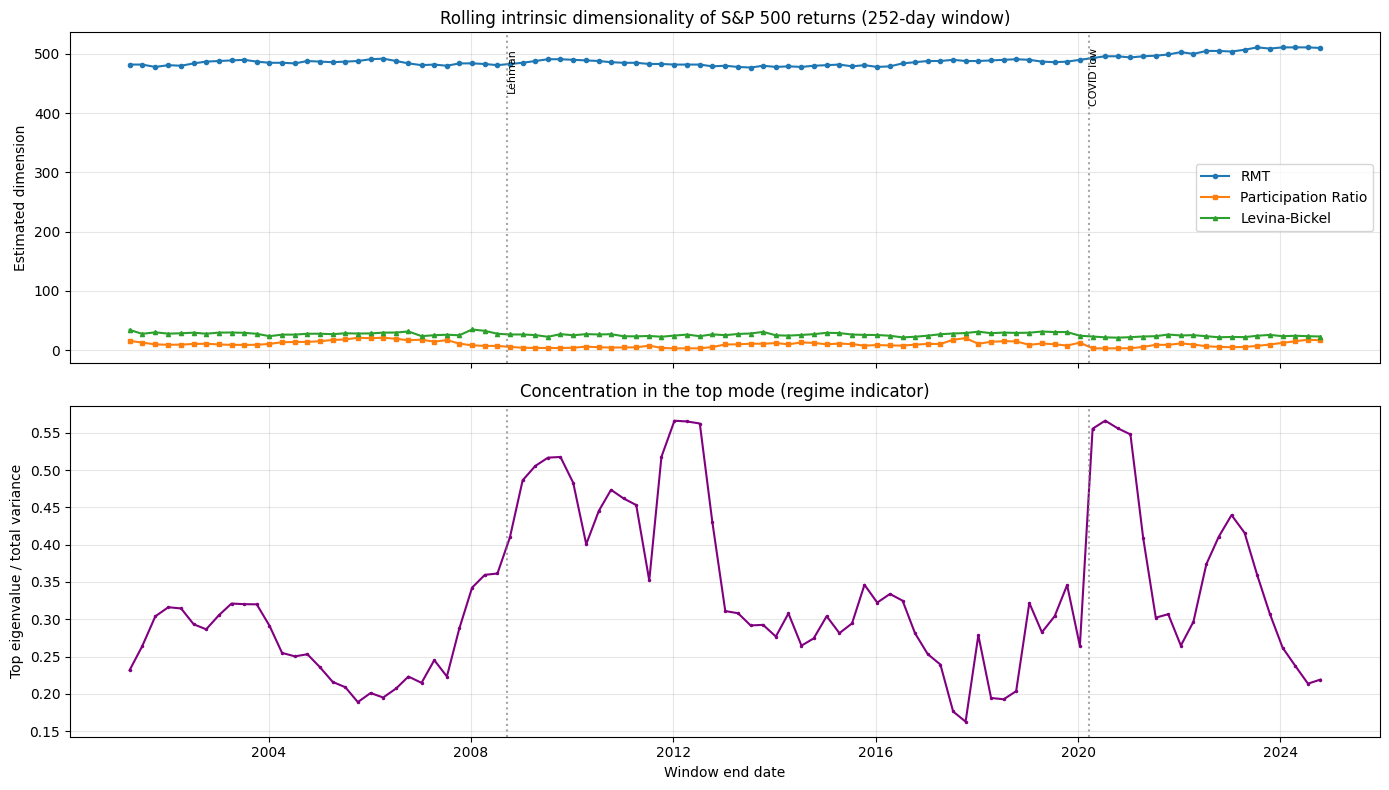

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(rolling.index, rolling["rmt"], label="RMT", marker="o", markersize=3)
axes[0].plot(rolling.index, rolling["pr"], label="Participation Ratio", marker="s", markersize=3)
axes[0].plot(rolling.index, rolling["lb"], label="Levina-Bickel", marker="^", markersize=3)
axes[0].set_ylabel("Estimated dimension")
axes[0].set_title("Rolling intrinsic dimensionality of S&P 500 returns (252-day window)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(rolling.index, rolling["top_eig_share"], color="purple", marker=".", markersize=3)
axes[1].set_ylabel("Top eigenvalue / total variance")
axes[1].set_xlabel("Window end date")
axes[1].set_title("Concentration in the top mode (regime indicator)")
axes[1].grid(alpha=0.3)

for date_str, label in [("2008-09-15", "Lehman"), ("2020-03-23", "COVID low")]:
    d = pd.Timestamp(date_str)
    if rolling.index.min() <= d <= rolling.index.max():
        for ax in axes:
            ax.axvline(d, color="gray", linestyle=":", alpha=0.7)
        axes[0].text(d, axes[0].get_ylim()[1] * 0.95, label, rotation=90, va="top", fontsize=8)

plt.tight_layout()
plt.show()

## 6. Robustness — random asset subsampling

Per the proposal's evaluation strategy: redraw the asset universe at 80% and recompute all three estimators across `B` random subsamples. A robust estimator should not move much when ~100 of 489 names are randomly removed. Reports mean, std, and coefficient of variation.

In [14]:
B_SUB = 100
SUB_FRAC = 0.80
rng_sub = np.random.default_rng(SEED)

p_sub = int(p * SUB_FRAC)
sub_results = {"rmt": [], "pr": [], "lb": []}

for _ in range(B_SUB):
    cols = rng_sub.choice(p, size=p_sub, replace=False)
    Xs = X[:, cols]
    cov_s = (Xs.T @ Xs) / (n - 1)
    es = eigh(cov_s, eigvals_only=True)[::-1]
    qs = p_sub / n

    # RMT (iterative σ²)
    s2_s = iter_sigma2(es, qs)
    edge_s = s2_s * (1 + np.sqrt(qs)) ** 2
    sub_results["rmt"].append(int((es > edge_s).sum()))

    # Participation ratio
    sub_results["pr"].append((es.sum() ** 2) / (es**2).sum())

    # Levina-Bickel
    nbrs_s = NearestNeighbors(n_neighbors=K + 1).fit(Xs)
    d_s, _ = nbrs_s.kneighbors(Xs)
    Tk_s = d_s[:, K]
    Tj_s = d_s[:, 1:K]
    lr_s = np.log((Tk_s[:, None] + 1e-12) / (Tj_s + 1e-12))
    ld_s = (K - 1) / lr_s.sum(axis=1)
    sub_results["lb"].append(ld_s[np.isfinite(ld_s)].mean())

stress = pd.DataFrame(
    {
        "estimator": ["RMT", "Participation Ratio", "Levina-Bickel"],
        "full_window": [rmt_dim, round(pr_dim, 2), round(lb_dim, 2)],
        "sub_mean": [np.mean(sub_results[k]) for k in ["rmt", "pr", "lb"]],
        "sub_std": [np.std(sub_results[k]) for k in ["rmt", "pr", "lb"]],
        "sub_cv_pct": [np.std(sub_results[k]) / np.mean(sub_results[k]) * 100 for k in ["rmt", "pr", "lb"]],
    }
)
print(f"80% asset subsampling, B={B_SUB} replicates")
print(stress.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

80% asset subsampling, B=100 replicates
          estimator  full_window  sub_mean  sub_std  sub_cv_pct
                RMT       149.00    114.92     3.19        2.77
Participation Ratio        10.24     10.17     0.29        2.80
      Levina-Bickel        29.48     28.75     0.62        2.15


## 7. Robustness — moving-block bootstrap confidence intervals

Resample the time axis in contiguous blocks of `BLOCK` days to preserve short-range autocorrelation (volatility clustering, day-of-week effects). For each replicate, reconstruct an `n × p` matrix by concatenating randomly-placed blocks and recompute all three estimators. Reports 95% percentile intervals — a narrow interval means the estimator is well-determined by this dataset; a wide one means the point estimate is noisy.

Moving-block bootstrap, B=200, block_len=20 days
          estimator  point  boot_mean  ci_2.5  ci_97.5  width
                RMT 149.00     489.00  489.00   489.00   0.00
Participation Ratio  10.24      10.33    7.17    14.62   7.45
      Levina-Bickel  29.48      15.08   10.09    21.00  10.91


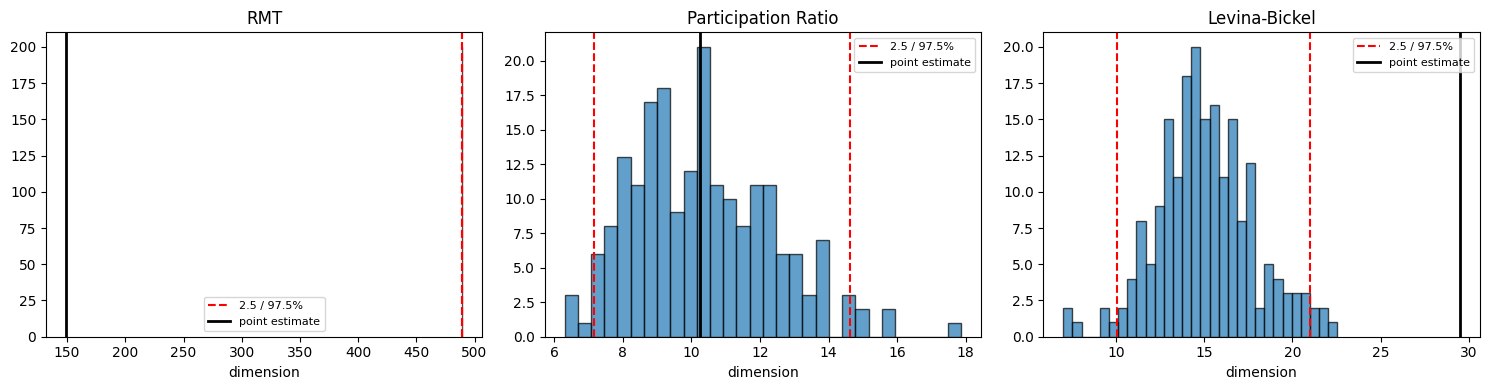

In [15]:
def estimators_from_X(Xb, K_=10):
    nb_, pb_ = Xb.shape
    Xb = Xb - Xb.mean(axis=0, keepdims=True)
    cov_b = (Xb.T @ Xb) / (nb_ - 1)
    eb = eigh(cov_b, eigvals_only=True)[::-1]
    qb = pb_ / nb_
    s2_b = iter_sigma2(eb, qb)
    edge_b = s2_b * (1 + np.sqrt(qb)) ** 2
    rmt_b = int((eb > edge_b).sum())
    pr_b = (eb.sum() ** 2) / (eb**2).sum()
    nbrs_b = NearestNeighbors(n_neighbors=K_ + 1).fit(Xb)
    db_, _ = nbrs_b.kneighbors(Xb)
    Tk_b, Tj_b = db_[:, K_], db_[:, 1:K_]
    lr_b = np.log((Tk_b[:, None] + 1e-12) / (Tj_b + 1e-12))
    ld_b = (K_ - 1) / lr_b.sum(axis=1)
    lb_b = ld_b[np.isfinite(ld_b)].mean()
    return rmt_b, pr_b, lb_b


B_BOOT = 200
BLOCK = 20  # ~one trading month
rng_boot = np.random.default_rng(SEED)

n_blocks = int(np.ceil(n / BLOCK))
boot = {"rmt": [], "pr": [], "lb": []}
for _ in range(B_BOOT):
    starts = rng_boot.integers(0, n - BLOCK + 1, size=n_blocks)
    idx = np.concatenate([np.arange(s, s + BLOCK) for s in starts])[:n]
    Xb = X_raw[idx]
    r_, p_, l_ = estimators_from_X(Xb, K_=K)
    boot["rmt"].append(r_)
    boot["pr"].append(p_)
    boot["lb"].append(l_)

ci_df = pd.DataFrame(
    {
        "estimator": ["RMT", "Participation Ratio", "Levina-Bickel"],
        "point": [rmt_dim, round(pr_dim, 2), round(lb_dim, 2)],
        "boot_mean": [np.mean(boot[k]) for k in ["rmt", "pr", "lb"]],
        "ci_2.5": [np.percentile(boot[k], 2.5) for k in ["rmt", "pr", "lb"]],
        "ci_97.5": [np.percentile(boot[k], 97.5) for k in ["rmt", "pr", "lb"]],
        "width": [np.percentile(boot[k], 97.5) - np.percentile(boot[k], 2.5) for k in ["rmt", "pr", "lb"]],
    }
)
print(f"Moving-block bootstrap, B={B_BOOT}, block_len={BLOCK} days")
print(ci_df.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
points = {"rmt": rmt_dim, "pr": pr_dim, "lb": lb_dim}
names = {"rmt": "RMT", "pr": "Participation Ratio", "lb": "Levina-Bickel"}
for ax, key in zip(axes, ["rmt", "pr", "lb"]):
    ax.hist(boot[key], bins=30, alpha=0.7, edgecolor="k")
    ax.axvline(np.percentile(boot[key], 2.5), color="red", linestyle="--", label="2.5 / 97.5%")
    ax.axvline(np.percentile(boot[key], 97.5), color="red", linestyle="--")
    ax.axvline(points[key], color="black", linewidth=2, label="point estimate")
    ax.set_title(names[key])
    ax.set_xlabel("dimension")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()